# Implementacion Del ejercicio

## Importacion de librerias

In [88]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import shapiro, normaltest, kstest
from tabulate import tabulate
from sklearn.impute import KNNImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import missingno as msno
from scipy.stats import chisquare
from scipy.stats import ks_2samp, wasserstein_distance

## Funciones usadas

In [53]:
def Summary(data, sheet):
    print(f"Hoja: {sheet}")

    # Crear la tabla de resumen
    resumen = {
        "Cantidad de filas": data.shape[0],
        "Cantidad de columnas": data.shape[1],
        "Datos faltantes": data.isnull().sum().sum(),
        "Filas duplicadas": data.duplicated().sum()
    }

    # Convertir el resumen en un DataFrame
    ResumenHoja = pd.DataFrame(resumen, index=["Resumen"])
    print("\nResumen:")
    display(ResumenHoja)

    print("\nEncabezado:")
    display(data.head())

In [54]:
def analizar_categoricas(df):
    resultados = []

    # Detectar variables categóricas (object, category o booleanas)
    categoricas = df.select_dtypes(include=['object', 'category', 'bool']).columns

    for col in categoricas:
        conteo = df[col].value_counts(dropna=False)
        proporcion = df[col].value_counts(normalize=True, dropna=False)
        nulos = df[col].isna().sum()

        # Tomamos la categoría más frecuente
        categoria_moda = conteo.index[0] if not conteo.empty else None
        frecuencia_moda = conteo.iloc[0] if not conteo.empty else None
        porcentaje_moda = proporcion.iloc[0] if not conteo.empty else None

        resultados.append({
            "variable": col,
            "cantidad_categorias": df[col].nunique(dropna=False),
            "categoria_mas_frecuente": categoria_moda,
            "frecuencia_mas_frecuente": frecuencia_moda,
            "porcentaje_mas_frecuente": porcentaje_moda,
            "nulos": nulos,
            "porcentaje_nulos": nulos / len(df)
        })
    
    return pd.DataFrame(resultados).sort_values(by="cantidad_categorias", ascending=False)

In [55]:
def Graficar_Categoricas(df, tipo="barra"):
    # Detectar variables categóricas
    categoricas = df.select_dtypes(include=['object', 'category', 'bool']).columns
    resultados = {}

    if len(categoricas) == 0:
        print("No se detectaron variables categóricas en el DataFrame.")
        return

    for col in categoricas:
        conteo = df[col].value_counts(dropna=False)  # incluir NaN si hay
        resultados[col] = conteo

        if tipo == "barra":
            plt.figure(figsize=(6,4))
            conteo.plot(kind="bar", color="skyblue", edgecolor="black")
            plt.title(f"Frecuencia de {col}")
            plt.xlabel(col)
            plt.ylabel("Frecuencia")
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()

        elif tipo == "pastel":
            plt.figure(figsize=(6,6))
            conteo.plot(kind="pie", autopct='%1.1f%%', 
                        colors=plt.cm.Set3.colors, startangle=90)
            plt.title(f"Distribución de {col}")
            plt.ylabel("")
            plt.tight_layout()
            plt.show()
        else:
            raise ValueError("El parámetro 'tipo' debe ser 'barra' o 'pastel'.")

    return resultados

In [56]:
def resumen_numericas(df):

    # Seleccionar columnas numéricas
    numericas = df.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns
    
    if len(numericas) == 0:
        print("No se detectaron variables numéricas en el DataFrame.")
        return None
    
    # Usamos describe() y agregamos info adicional
    resumen = df[numericas].describe().T  # Transpuesto para mayor claridad
    resumen["varianza"] = df[numericas].var()
    resumen["mediana"] = df[numericas].median()
    
    return resumen

In [57]:
def graficar_numericas(df):

    # Detectar variables numéricas
    numericas = df.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns

    if len(numericas) == 0:
        print("No se detectaron variables numéricas en el DataFrame.")
        return

    for col in numericas:
        plt.figure(figsize=(12,4))

        # Histograma
        plt.subplot(1,2,1)
        df[col].hist(bins=20, color="skyblue", edgecolor="black")
        plt.title(f"Histograma de {col}")
        plt.xlabel(col)
        plt.ylabel("Frecuencia")

        # Boxplot
        plt.subplot(1,2,2)
        plt.boxplot(df[col].dropna(), vert=False, patch_artist=True,
                    boxprops=dict(facecolor="lightgreen", color="black"),
                    medianprops=dict(color="red"))
        plt.title(f"Boxplot de {col}")
        plt.xlabel(col)

        plt.tight_layout()
        plt.show()

In [58]:
def prueba_normalidad(df, alpha=0.05):
    resultados = []

    # Detectar variables numéricas
    numericas = df.select_dtypes(include=[np.number]).columns

    for col in numericas:
        serie = df[col].dropna()

        if len(serie) < 8:  # muy pocas muestras → no confiable
            resultados.append({
                "variable": col,
                "n_muestras": len(serie),
                "shapiro_p": np.nan,
                "dagostino_p": np.nan,
                "ks_p": np.nan,
                "es_normal (alpha=0.05)": "Muestra insuficiente"
            })
            continue

        # Shapiro-Wilk (solo si n <= 5000, más grande no recomendado)
        stat_shapiro, p_shapiro = shapiro(serie) if len(serie) <= 5000 else (np.nan, np.nan)

        # D’Agostino y Pearson
        stat_dagostino, p_dagostino = normaltest(serie)

        # Kolmogorov-Smirnov contra normal estándar
        stat_ks, p_ks = kstest(
            (serie - serie.mean()) / serie.std(ddof=0), 'norm'
        )

        # Veredicto final
        es_normal = (
            (np.isnan(p_shapiro) or p_shapiro > alpha) and
            (p_dagostino > alpha) and
            (p_ks > alpha)
        )

        resultados.append({
            "variable": col,
            "n_muestras": len(serie),
            "shapiro_p": p_shapiro,
            "dagostino_p": p_dagostino,
            "ks_p": p_ks,
            "es_normal (alpha=0.05)": es_normal
        })

    return pd.DataFrame(resultados).sort_values(by="es_normal (alpha=0.05)", ascending=False)

In [59]:
def mapa_calor_nulos(df, figsize=(10,6), cmap="viridis"):
    plt.figure(figsize=figsize)
    sns.heatmap(df.isnull(), 
                cbar=False, 
                cmap=cmap, 
                yticklabels=False)
    plt.title("Mapa de calor de valores faltantes", fontsize=14)
    plt.show()

In [60]:
def contar_na_numericas(df):

    # Detectar variables numéricas
    numericas = df.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns

    if len(numericas) == 0:
        print("No se detectaron variables numéricas en el DataFrame.")
        return None

    # Contar NAs en cada variable numérica
    na_counts = df[numericas].isna().sum()

    return na_counts

## Cargado y revision inicial de los datos

In [61]:
df = pd.read_csv("Base_imputacion_mixta_1000.csv")

In [62]:
Summary(df,"Datos")

Hoja: Datos

Resumen:


,Cantidad de filas,Cantidad de columnas,Datos faltantes,Filas duplicadas
Resumen,1000,12,1850,0



Encabezado:


,fecha,sexo,ciudad,nivel_educativo,segmento,estado_civil,edad,altura_cm,ingresos,gasto_mensual,puntuacion_credito,demanda
0,2024-01-01,F,Medellín,NaN,B,Unión libre,19.0,161.821754,3574.753806,1832.731832,640.465372,119.202995
1,2024-01-02,F,Barranquilla,NaN,B,NaN,52.0,167.819566,3163.626815,NaN,533.108430,124.457874
2,2024-01-03,M,Bogotá,Secundaria,B,Soltero/a,38.0,165.756219,2765.672259,1219.535074,491.016910,NaN
3,2024-01-04,F,Bogotá,NaN,B,Casado/a,57.0,160.642670,4320.397345,1908.324816,NaN,129.426792
4,2024-01-05,M,Cali,Técnico,B,Soltero/a,67.0,151.402909,NaN,1887.385697,610.213994,133.916319


Observamos prescencia de datos faltantes, en total 1850, ademas de 1000 filas y 12 columnas con 0 filas duplicadas, a continuacion revisaremos la adecuada lectura de los tipos de datos

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   fecha               1000 non-null   object 
 1   sexo                980 non-null    object 
 2   ciudad              950 non-null    object 
 3   nivel_educativo     900 non-null    object 
 4   segmento            800 non-null    object 
 5   estado_civil        650 non-null    object 
 6   edad                970 non-null    float64
 7   altura_cm           920 non-null    float64
 8   ingresos            880 non-null    float64
 9   gasto_mensual       750 non-null    float64
 10  puntuacion_credito  500 non-null    float64
 11  demanda             850 non-null    float64
dtypes: float64(6), object(6)
memory usage: 93.9+ KB


Observamos que todos los datos están adecuadamente detectados excepto por fecha que está siendo detectada como un object

In [64]:
df["fecha"] = pd.to_datetime(df["fecha"], format="%Y-%m-%d")

## Analisis exploratorio de datos

In [65]:
analizar_categoricas(df)

,variable,cantidad_categorias,categoria_mas_frecuente,frecuencia_mas_frecuente,porcentaje_mas_frecuente,nulos,porcentaje_nulos
1,ciudad,6,Bogotá,307,0.307,50,0.05
4,estado_civil,5,NaN,350,0.350,350,0.35
2,nivel_educativo,5,Secundaria,317,0.317,100,0.10
3,segmento,4,B,457,0.457,200,0.20
0,sexo,3,F,518,0.518,20,0.02


vemos que la cantidad de nulos para la variable:
- ciudad: igual que 0.05(imputacion simple por moda)
- estado_civil: mayor que 0.05 peligrosamente alto
- nivel educativo: mayor que 0.05 medianamente alto
- segmento: mayor que 0.05 (alto)
- sexo: menor que 0.05(imputacion simple por moda)

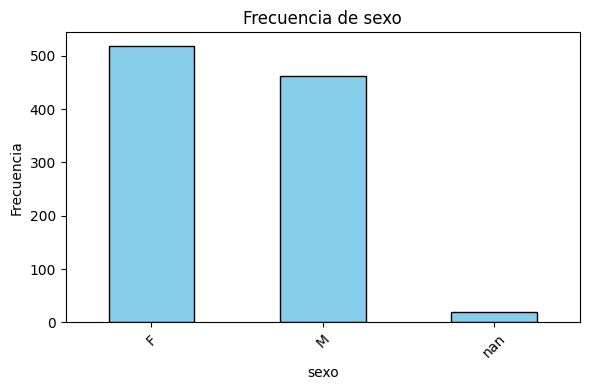

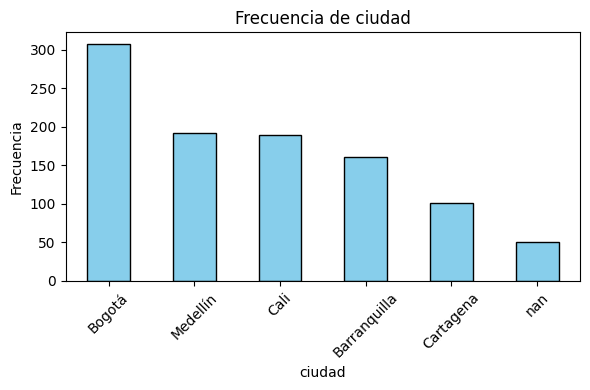

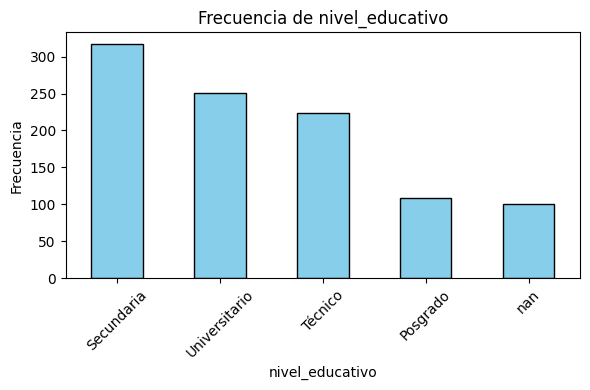

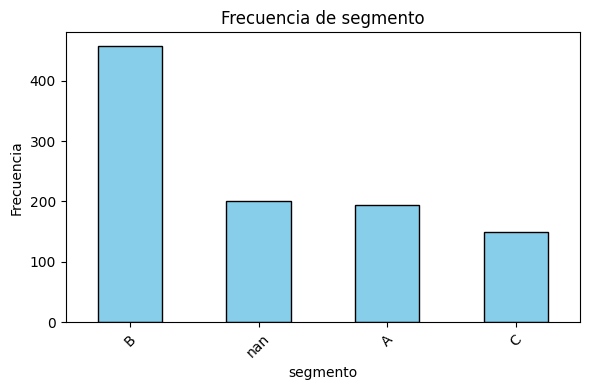

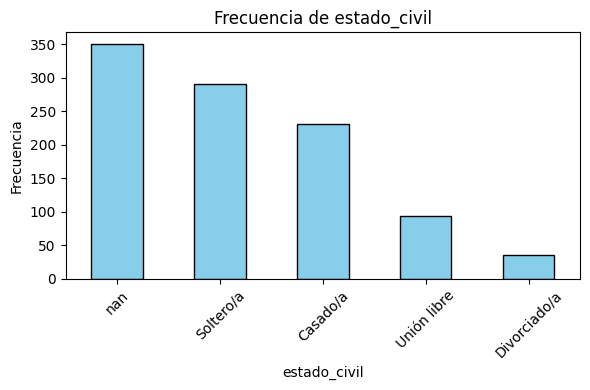

{'sexo': sexo
 F      518
 M      462
 NaN     20
 Name: count, dtype: int64,
 'ciudad': ciudad
 Bogotá          307
 Medellín        192
 Cali            189
 Barranquilla    161
 Cartagena       101
 NaN              50
 Name: count, dtype: int64,
 'nivel_educativo': nivel_educativo
 Secundaria       317
 Universitario    251
 Técnico          224
 Posgrado         108
 NaN              100
 Name: count, dtype: int64,
 'segmento': segmento
 B      457
 NaN    200
 A      194
 C      149
 Name: count, dtype: int64,
 'estado_civil': estado_civil
 NaN             350
 Soltero/a       290
 Casado/a        231
 Unión libre      93
 Divorciado/a     36
 Name: count, dtype: int64}

In [66]:
Graficar_Categoricas(df)

se observa un ligero desbalance para todas las clases excepto sexo, especialmente notable en la variable segmento donde la mayoria de las observaciones(sin contar na) pertenecen a la clase B(clase B: 457, clase A:194, clase C: 149)

In [67]:
resumen_numericas(df)

,count,mean,std,min,25%,50%,75%,max,varianza,mediana
edad,970.0,42.861856,14.621382,18.000000,30.000000,43.000000,55.000000,69.000000,2.137848e+02,43.000000
altura_cm,920.0,167.760096,9.275530,140.000000,161.488768,167.714614,173.999069,195.766921,8.603545e+01,167.714614
ingresos,880.0,3681.294745,1079.326096,487.662547,2999.416229,3669.620507,4375.093656,7016.246936,1.164945e+06,3669.620507
gasto_mensual,750.0,1687.810749,582.070174,100.000000,1309.239768,1676.193764,2063.260990,3532.593603,3.388057e+05,1676.193764
puntuacion_credito,500.0,599.077500,79.828186,373.657944,544.467843,599.692595,653.345068,823.539585,6.372539e+03,599.692595
demanda,850.0,160.305759,25.357794,99.875828,139.505538,160.721251,181.100754,222.093047,6.430177e+02,160.721251


In [68]:
contar_na_numericas(df)

edad                   30
altura_cm              80
ingresos              120
gasto_mensual         250
puntuacion_credito    500
demanda               150
dtype: int64

In [69]:
contar_na_numericas(df) / len(df)

edad                  0.03
altura_cm             0.08
ingresos              0.12
gasto_mensual         0.25
puntuacion_credito    0.50
demanda               0.15
dtype: float64

observamos que para la variable:
- edad: menor de 0.05 (imputacion simple por media o mediana si no es normal)
- altura: mayor de 0.05 (no tan alto)
- ingresos: mayor que 0.05 (medio)
- gasto mensual: mayor que 0.05 (un poco alto)
- puntuacion_credito mayor que 0.40 (peligrosamente alto)
- demanda: mayor que 0.05 (medianamente alto)

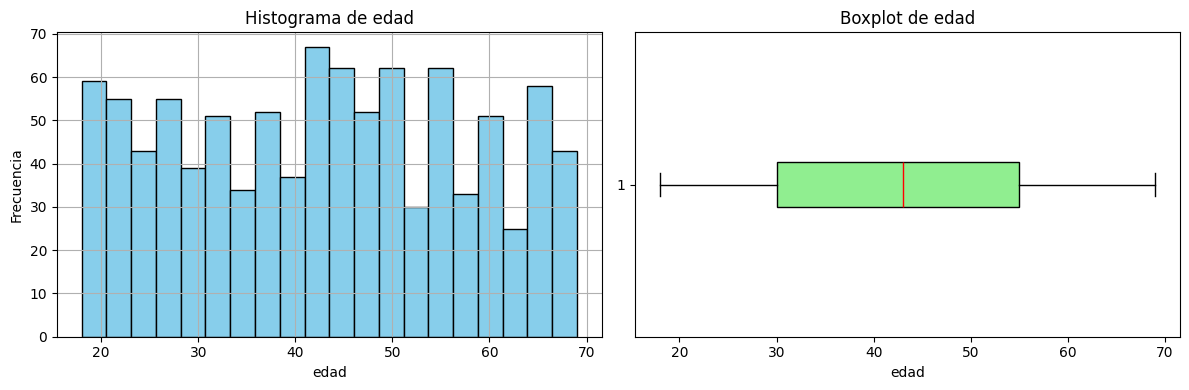

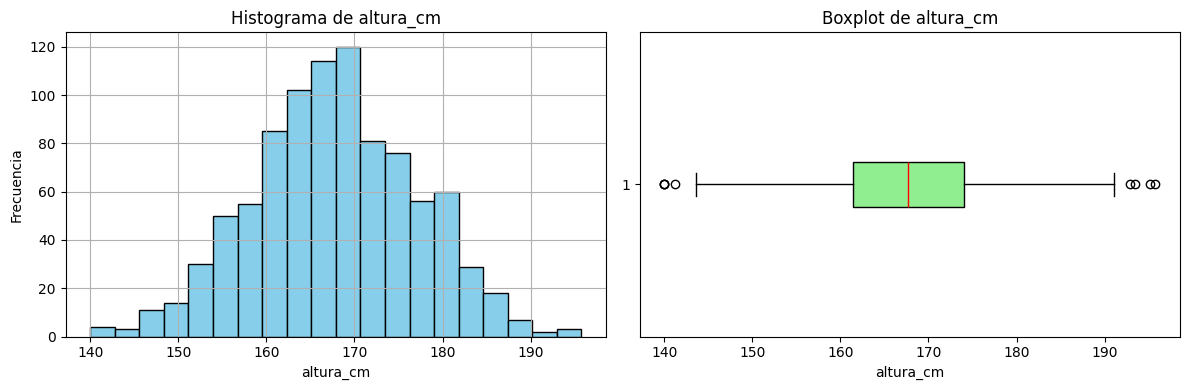

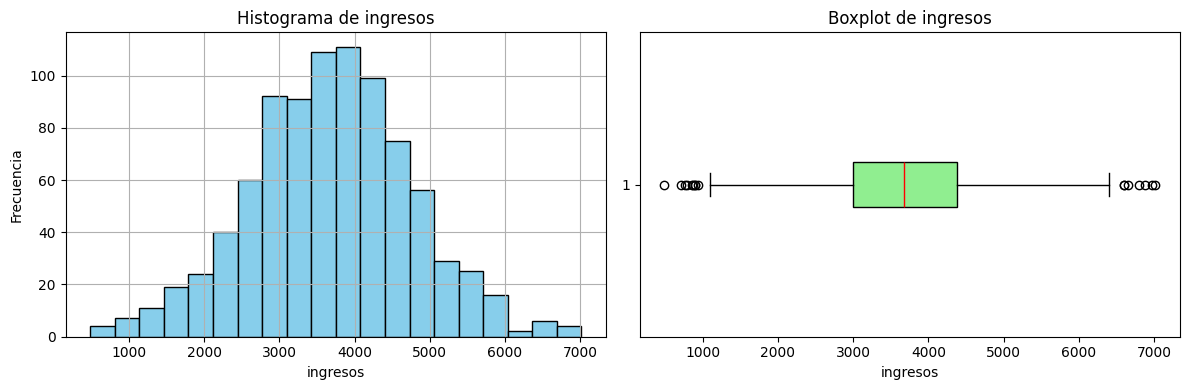

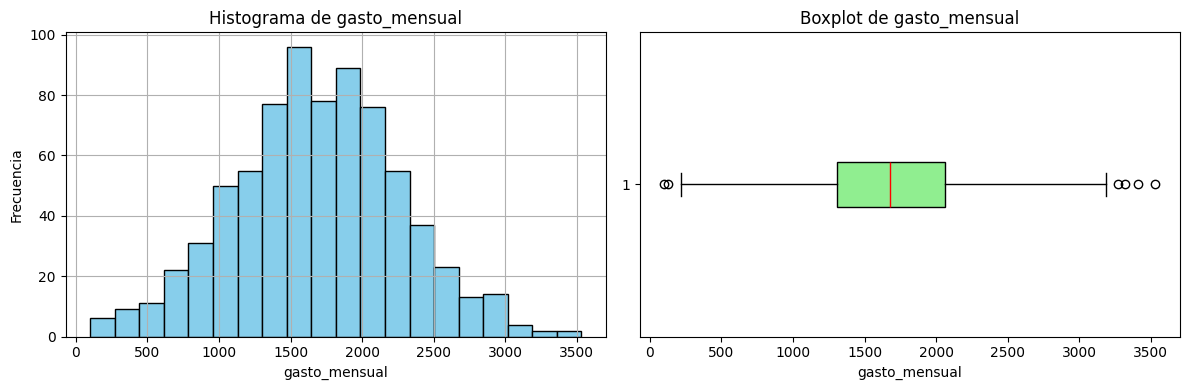

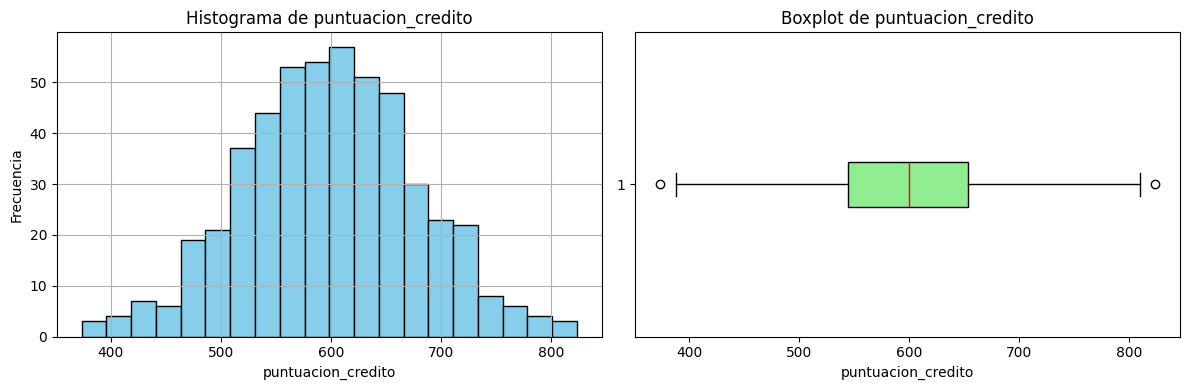

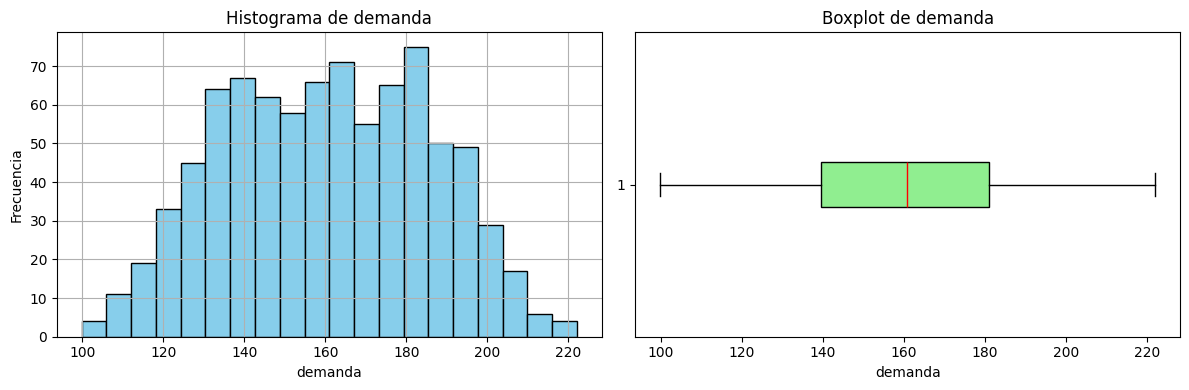

In [70]:
graficar_numericas(df)

mapa de calor de los valores faltantes

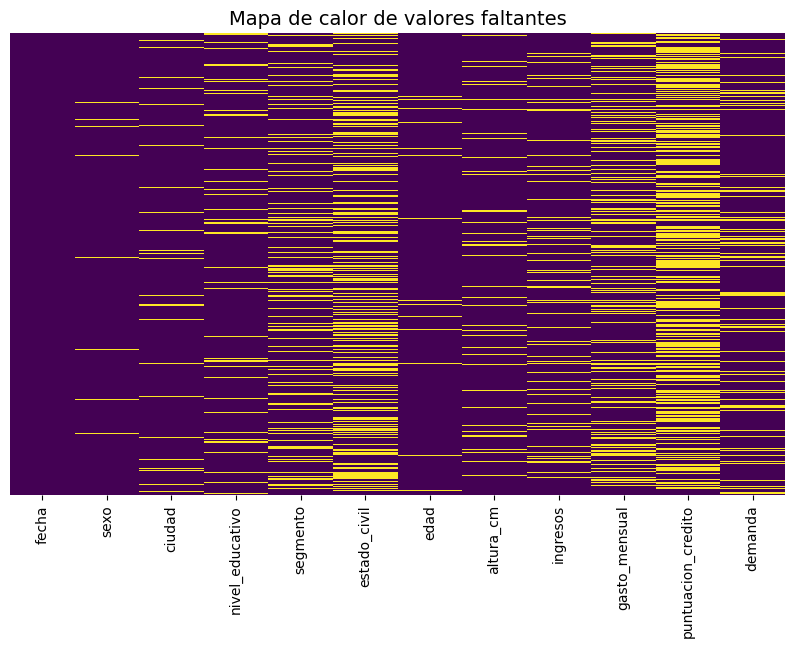

In [71]:
mapa_calor_nulos(df)

In [72]:
prueba_normalidad(df)

,variable,n_muestras,shapiro_p,dagostino_p,ks_p,es_normal (alpha=0.05)
1,altura_cm,920,5.911472e-01,7.946680e-01,0.725425,True
2,ingresos,880,3.244752e-01,6.173557e-01,0.899760,True
3,gasto_mensual,750,6.752081e-01,8.791065e-01,0.961382,True
4,puntuacion_credito,500,9.405074e-01,9.651871e-01,0.997282,True
0,edad,970,1.132185e-15,9.628678e-93,0.000063,False
5,demanda,850,1.129628e-07,1.958694e-19,0.025404,False


observamos que se cumple normalidad para todas las variables excepto para demanda y edad

## Clasificacion de datos faltantes segun lo observado

Debido a que la variable de fechas no posee relevancia sobre el resto de datos vamos a trabajar como si no fuese una serie de tiempo debido a que no existe una correlacion entre el tiempo y las variables

- **ciudad (5% nulos)**
- - Es poco probable que alguien omita aleatoriamente su ciudad.
- - Generalmente depende de otra variable (ej: personas de cierto segmento/sexo no la reportan).
- -  MAR
- **estado_civil (35% nulos)**
- - Muy alto nivel de ausencia.
- - Usualmente quienes no responden su estado civil lo hacen porque no quieren revelarlo osea depende de la propia variable.
- - MNAR
- **nivel_educativo (10% nulos)**
- - Probable que dependa de otras variables como edad o ingresos (ej: personas jóvenes aún no completan estudios).
- - MAR
- **segmento (20% nulos)**
- - Si “segmento” es asignado (ej: por gasto/ingresos), los nulos se deben a que faltan esas variables relacionadas.
- - MAR
- **sexo (2% nulos)** 
- - Puede ser MCAR si simplemente faltan por error de captura.
- - Pero en encuestas reales, a veces es MNAR porque alguien no desea identificar su género.
- - MCAR/MNAR (según el contexto; si es sistema administrativo, casi seguro MCAR; si es encuesta, más bien MNAR).

- **edad (3% nulos)**
- - Suele ser un dato básico, faltante por errores de captura o descuido.
- - Poco probable que alguien oculte su edad en un sistema estructurado.
- - MCAR
- **altura_cm (8% nulos)**
- - Variable secundaria en muchos contextos, normalmente faltan porque no se midió.
- - No suele depender de la propia altura.
- - MCAR
- **ingresos (12% nulos)**
- - Aquí sí hay sesgo: personas con ingresos muy altos o muy bajos pueden omitirlo.
- - Entonces depende de la propia variable.
- - MNAR
- **gasto_mensual (25% nulos)**
- - Al estar relacionado con ingresos, probablemente falta cuando no se conocen/declaran los ingresos.
- - Depende de otra variable observada (ingresos).
- - MAR
- **puntuacion_credito (50% nulos)**
- - Altísimo faltante. Usualmente pasa cuando la persona no tiene historial crediticio.
- - Eso depende directamente de la propia variable (quien no tiene crédito = NA).
- - MNAR
- **demanda (15% nulos)**
- - Si es una variable de comportamiento (ej: consumo/uso de un producto), puede faltar cuando no hay registro de compra.
- - Eso depende de la propia variable.
- - MNAR

Resumen clasificación categoricas:
- MCAR: sexo (en sistemas administrativos)
- MAR: ciudad, nivel_educativo, segmento
- MNAR: estado_civil, sexo (en encuestas sensibles)

Resumen clasificación numéricas:
- MCAR: edad, altura_cm
- MAR: gasto_mensual
- MNAR: ingresos, puntuacion_credito, demanda

## Discusion sobre imputabilidad

### Variables numericas:

edad (3%) muy fáci, imputacion por media o mediana. No cumple normalidad asi que por mediana

altura_cm (8%) fácil, se pueden usar técnicas simples (media/mediana) o modelos más finos para precisión. Cumple normalidad asi que por media

ingresos (12%) moderada, Recomendable usar métodos más robustos como KNN imputer o regresión múltiple.

demanda (15%) moderada, si es predictora usar metodos robustos para imputar si es predictora eliminar registros

gasto_mensual (25%) difícil, pero viable con técnicas avanzadas. Aquí conviene usar modelos de imputación multivariada (MICE, KNN) porque está muy relacionado con ingresos

puntuacion_credito (50%) muy difícil, riesgo alto de sesgo

### Variables cualitativas:

sexo (2%)  muy fácil, Muy fácil de imputar, incluso con la moda sin mucho riesgo(sin desbalance).

ciudad (5%)  fácil, se puede usar moda con riesgo a generar desbalance

nivel_educativo (10%)  media-alta, imputable con moda, o mejor con variables relacionadas (edad, ingresos).

segmento (20%)  media. Mejor usar algoritmos predictivos (árboles, KNN) basados en gasto/ingresos.

estado_civil (35%)  difícil, alto riesgo:
- Imputar usando modelos supervisados (en función de edad, sexo, ingresos, etc.)
- O crear una categoría especial “desconocido” para no perder información.

## Imputacion

In [73]:
# Variables numéricas
numeric_vars = ["edad", "altura_cm", "ingresos", "demanda", "gasto_mensual", "puntuacion_credito"]

# Copia de trabajo
df_num = df[numeric_vars].copy()

# 1. Edad (3%) → usar mediana
df_num["edad"] = df_num["edad"].fillna(df_num["edad"].median())

# 2. Altura (8%) → usar media
df_num["altura_cm"] = df_num["altura_cm"].fillna(df_num["altura_cm"].mean())

# 3. Ingresos (12%) → imputar con KNN
knn_imputer = KNNImputer(n_neighbors=5)
df_num[["ingresos"]] = knn_imputer.fit_transform(df_num[["ingresos"]])

# 4. Demanda (15%) → aquí depende del rol
# Si es predictora: imputar con KNN
df_num[["demanda"]] = knn_imputer.fit_transform(df_num[["demanda"]])

# Si es variable objetivo: mejor eliminar filas con NA
# df = df.dropna(subset=["demanda"])

# 5. Gasto_mensual (25%) → imputar con MICE (IterativeImputer)
mice_imputer = IterativeImputer(random_state=42, max_iter=10)
df_num[["gasto_mensual"]] = mice_imputer.fit_transform(df_num[["gasto_mensual"]])


In [ ]:
# Variables categóricas
cat_vars = ["sexo", "ciudad", "nivel_educativo", "segmento", "estado_civil"]
df_cat = df[cat_vars].copy()

# 1. Sexo (2%) → imputación por moda (sin riesgo de desbalance)
df_cat["sexo"] = df_cat["sexo"].fillna(df_cat["sexo"].mode()[0])

# 2. Ciudad (5%) → moda (pero ojo con desbalance)
df_cat["ciudad"] = df_cat["ciudad"].fillna(df_cat["ciudad"].mode()[0])

# 3. Nivel educativo (10%) → 
# Opción A: simple con moda
df_cat["nivel_educativo"] = df_cat["nivel_educativo"].fillna(df_cat["nivel_educativo"].mode()[0])

# 4. Segmento (20%) → imputación predictiva (KNN con gasto/ingresos)
encoder_seg = OrdinalEncoder()
df_encoded_seg = encoder_seg.fit_transform(df_cat[["segmento"]])
df_encoded_seg = pd.DataFrame(df_encoded_seg, columns=["segmento_encoded"], index=df_cat.index)

predictors_seg = df[["ingresos", "gasto_mensual"]].copy()
predictors_seg["segmento_encoded"] = df_encoded_seg

imputed_seg = knn_imputer.fit_transform(predictors_seg)

# Inverse transform necesita 2D, pero luego se aplana para asignar
segmento_imputed = encoder_seg.inverse_transform(imputed_seg[:, [-1]])
df_cat["segmento"] = segmento_imputed.ravel()

# 5. Estado civil (35%) → alto riesgo
# Estrategia: crear categoría especial "desconocido"
df_cat["estado_civil"] = df_cat["estado_civil"].fillna("desconocido")


## Representacion de la imputacion

Antes de imputación:
Después de imputación:


<Axes: >

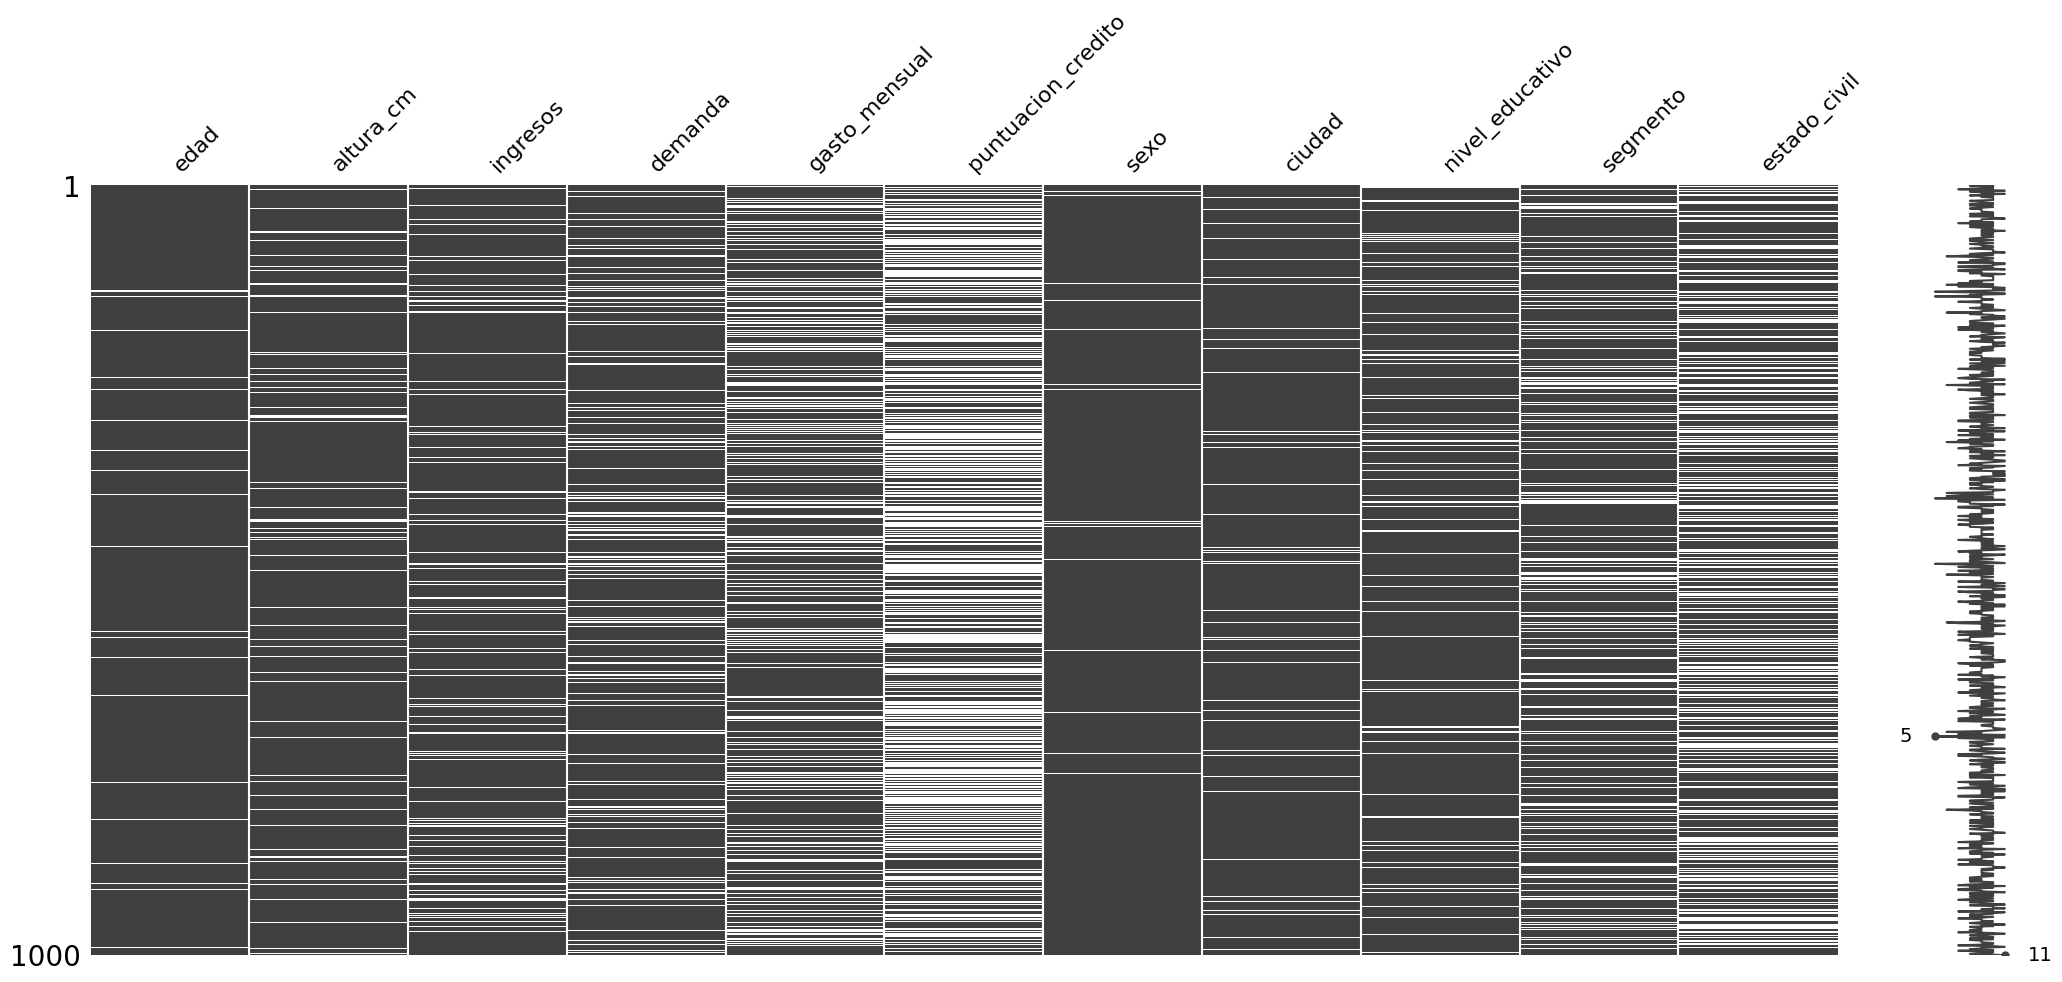

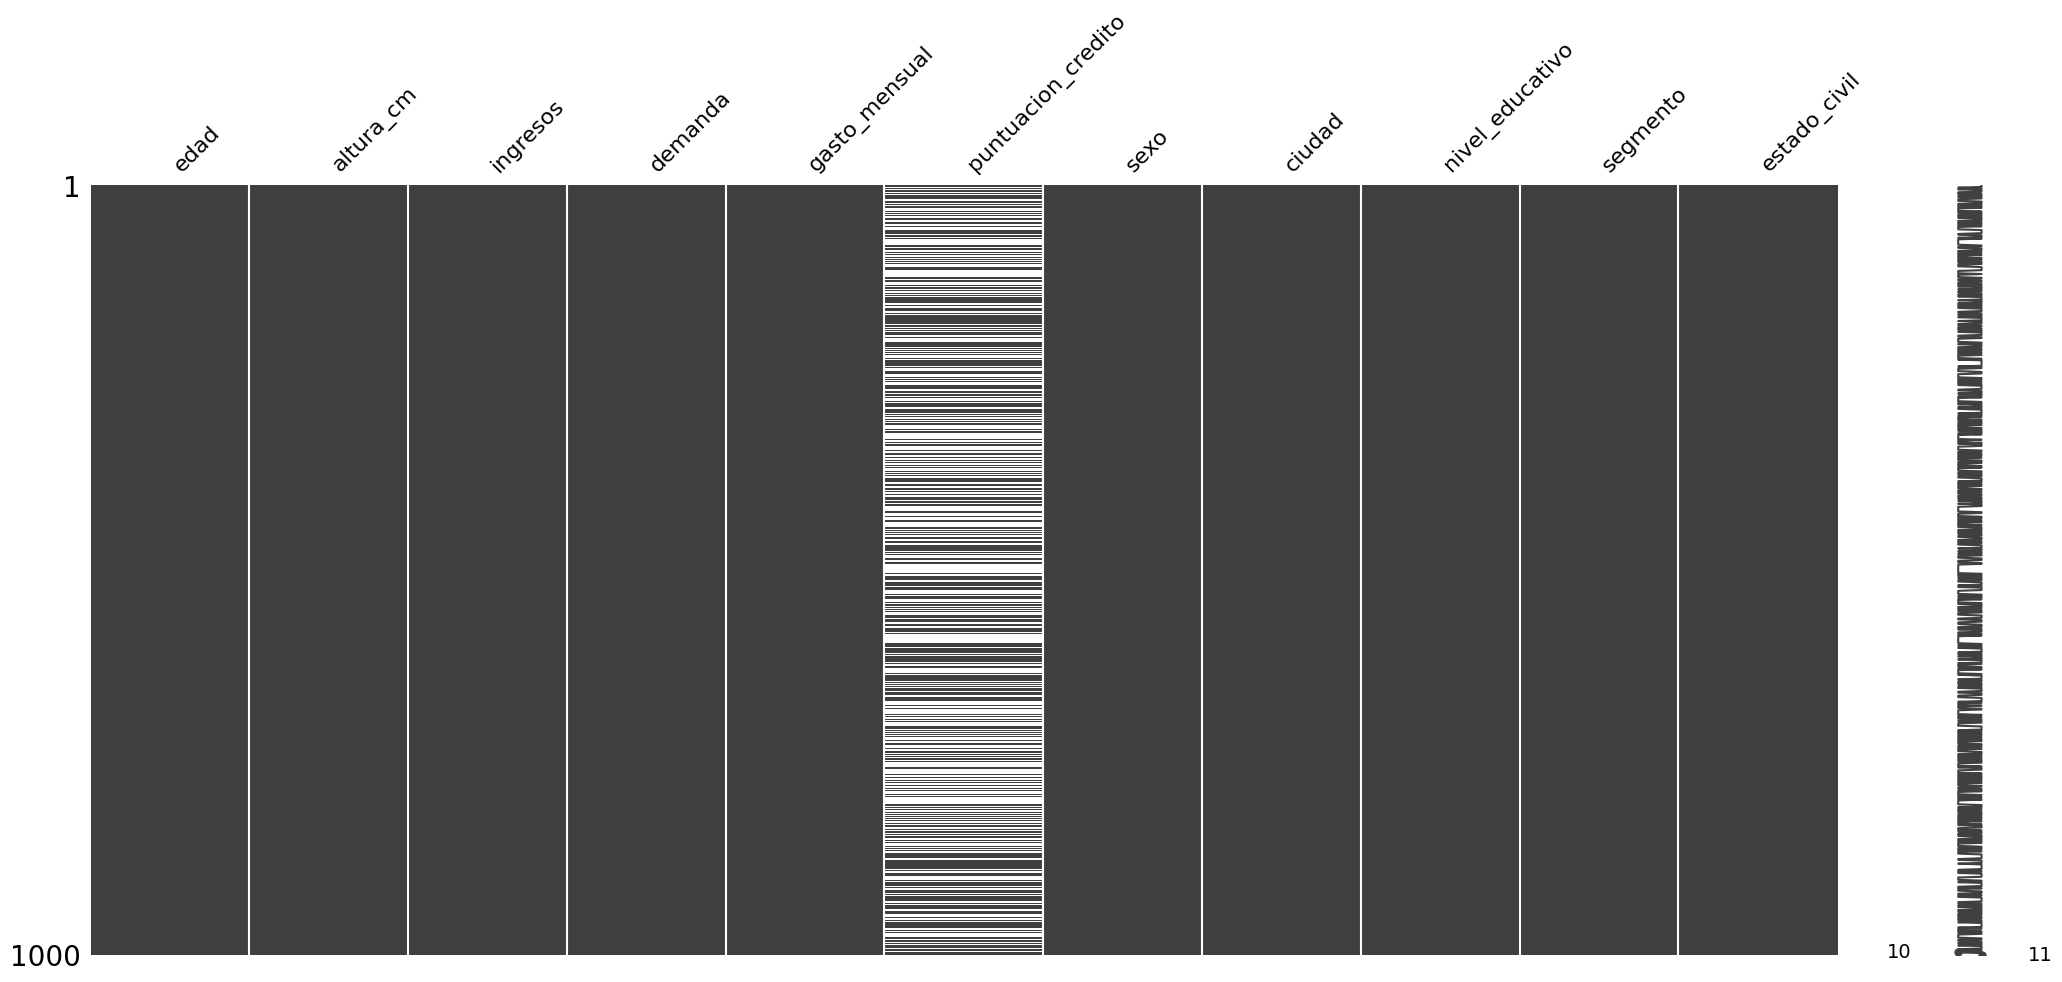

In [78]:
print("Antes de imputación:")
msno.matrix(df[numeric_vars + cat_vars])

print("Después de imputación:")
msno.matrix(pd.concat([df_num, df_cat], axis=1))

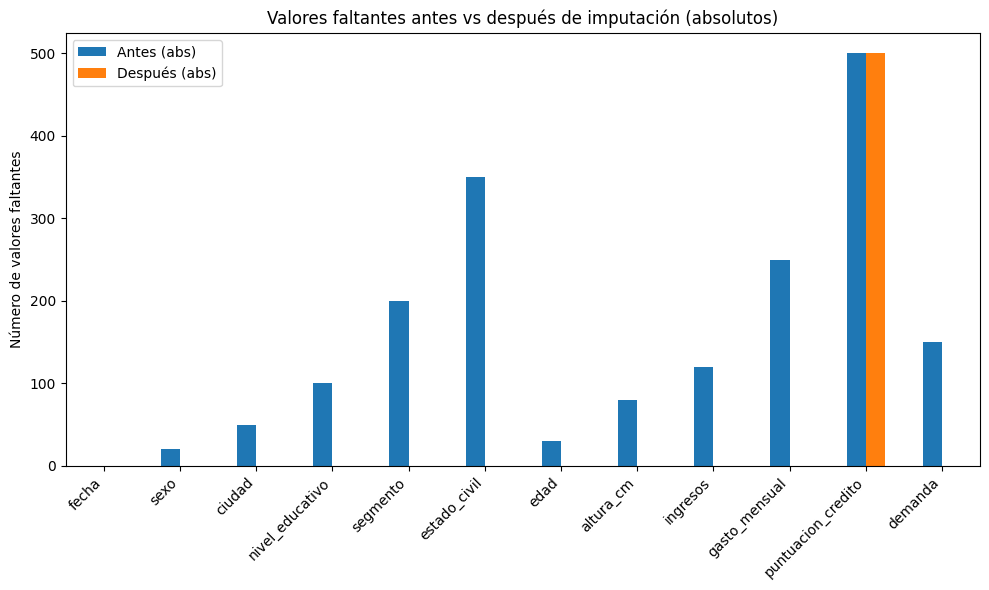

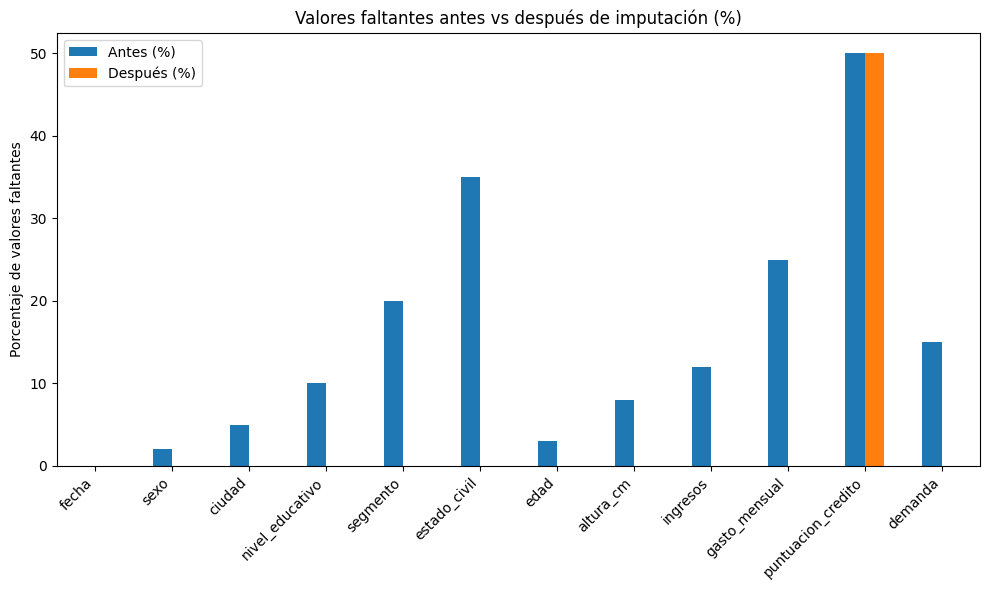

In [84]:
# --- Conteo de nulos ---
missing_before = df.isna().sum()

# Concatenar numéricas y categóricas imputadas (usando concat en vez de append)
missing_after = pd.concat([df_num.isna().sum(), df_cat.isna().sum()])

# Reindexar para que coincidan las columnas
missing_after = missing_after.reindex(missing_before.index)

# Total de filas (para calcular %)
n_rows = df.shape[0]

# --- Resumen ---
missing_summary = pd.DataFrame({
    "Antes (abs)": missing_before,
    "Después (abs)": missing_after,
    "Antes (%)": (missing_before / n_rows) * 100,
    "Después (%)": (missing_after / n_rows) * 100
})

# --- Gráfico en valores absolutos ---
missing_summary[["Antes (abs)", "Después (abs)"]].plot(
    kind="bar",
    figsize=(10,6),
    title="Valores faltantes antes vs después de imputación (absolutos)"
)
plt.ylabel("Número de valores faltantes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# --- Gráfico en porcentaje ---
missing_summary[["Antes (%)", "Después (%)"]].plot(
    kind="bar",
    figsize=(10,6),
    title="Valores faltantes antes vs después de imputación (%)"
)
plt.ylabel("Porcentaje de valores faltantes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

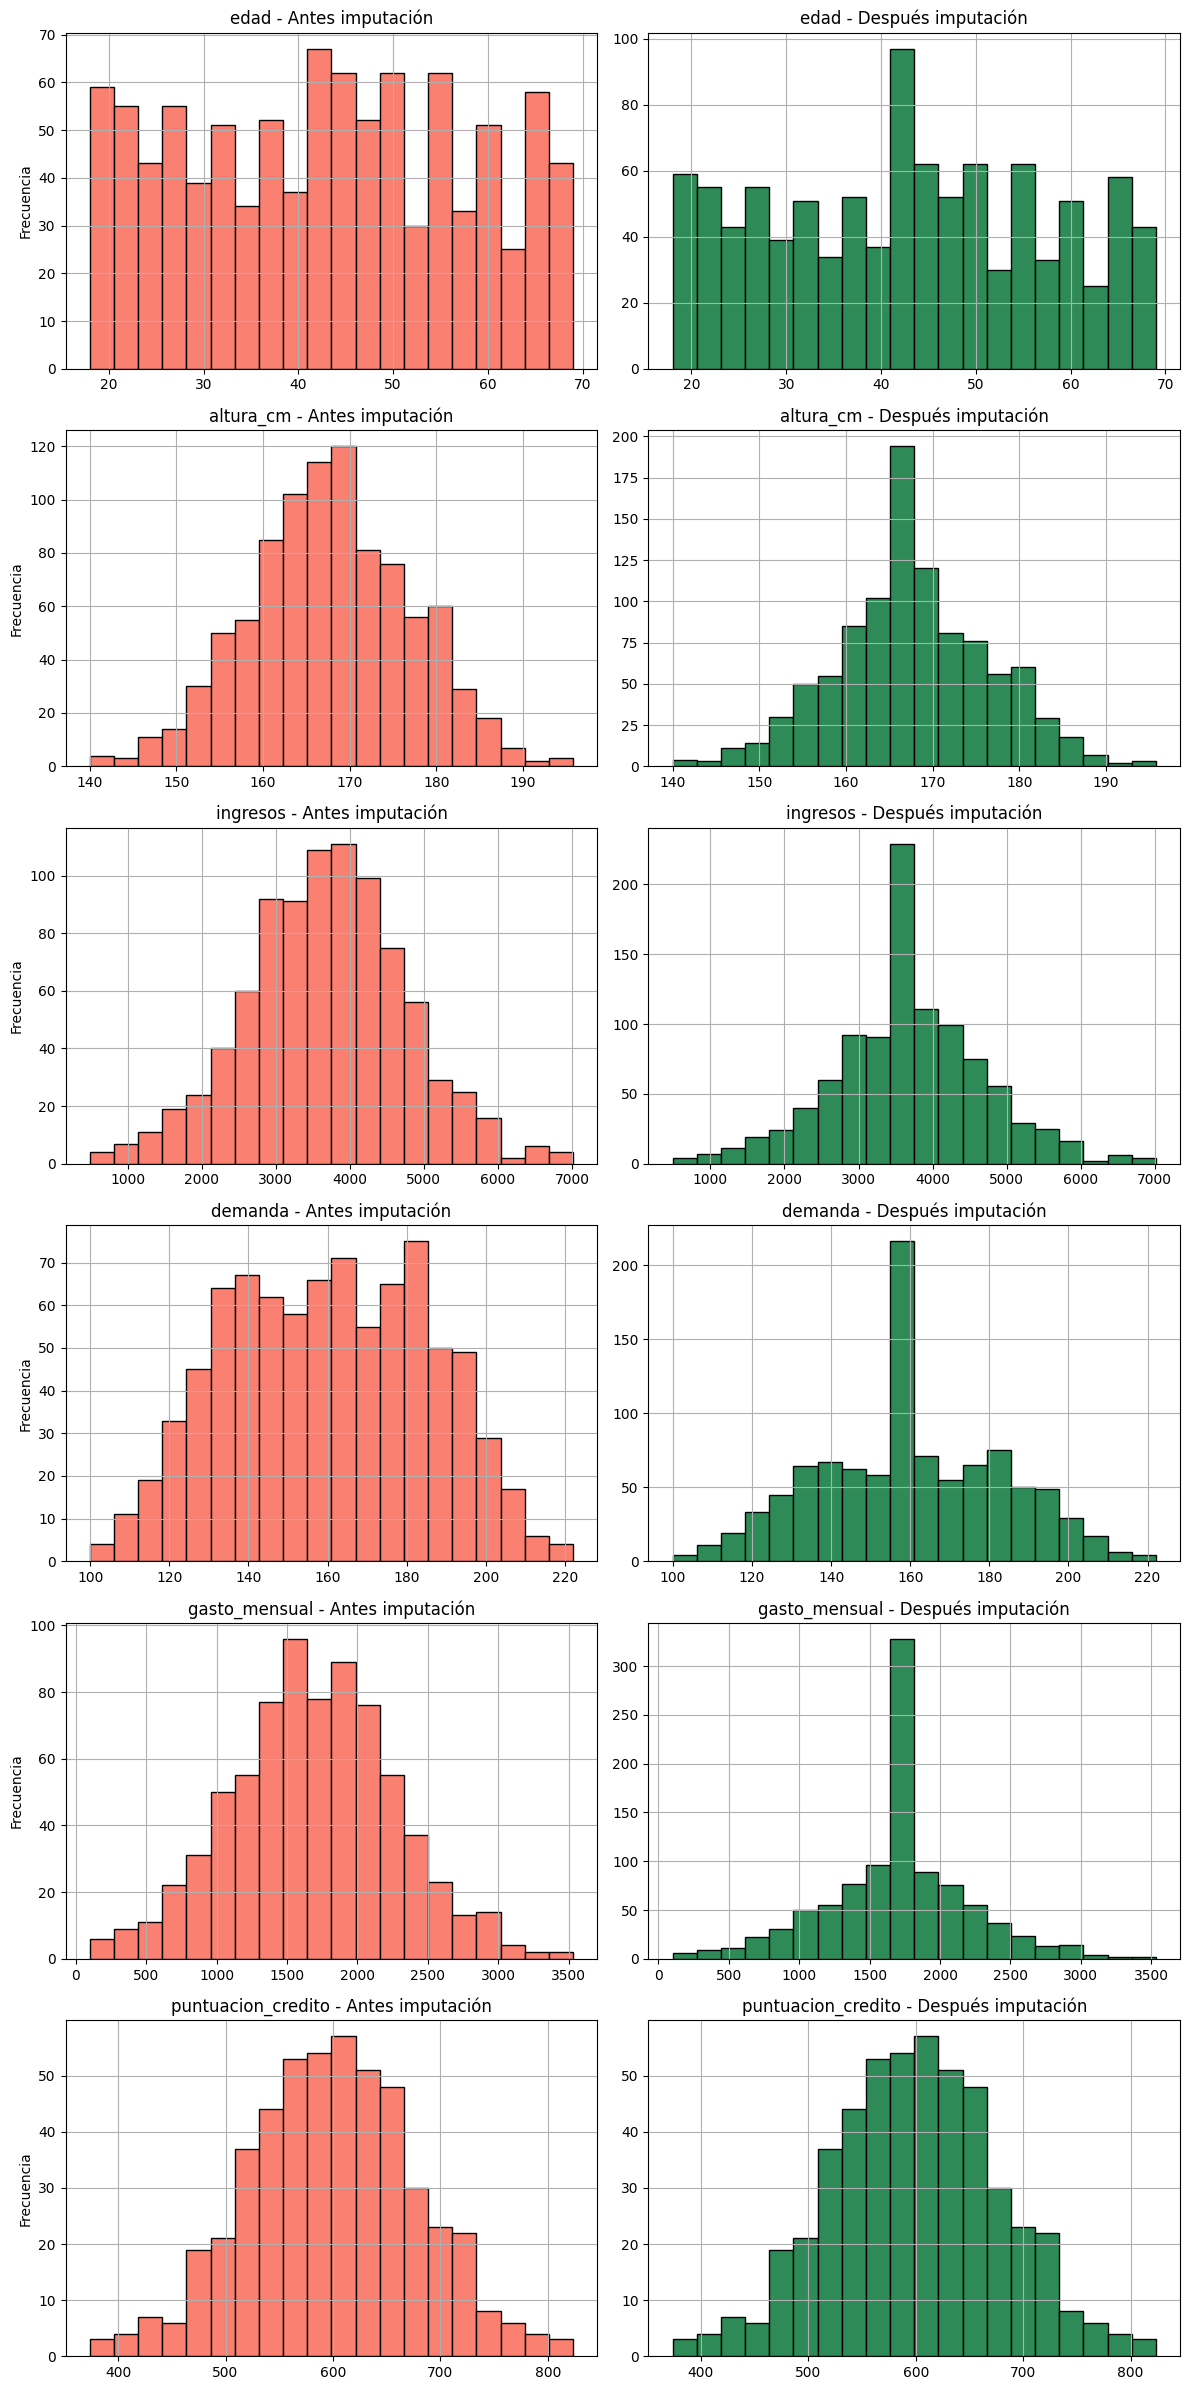

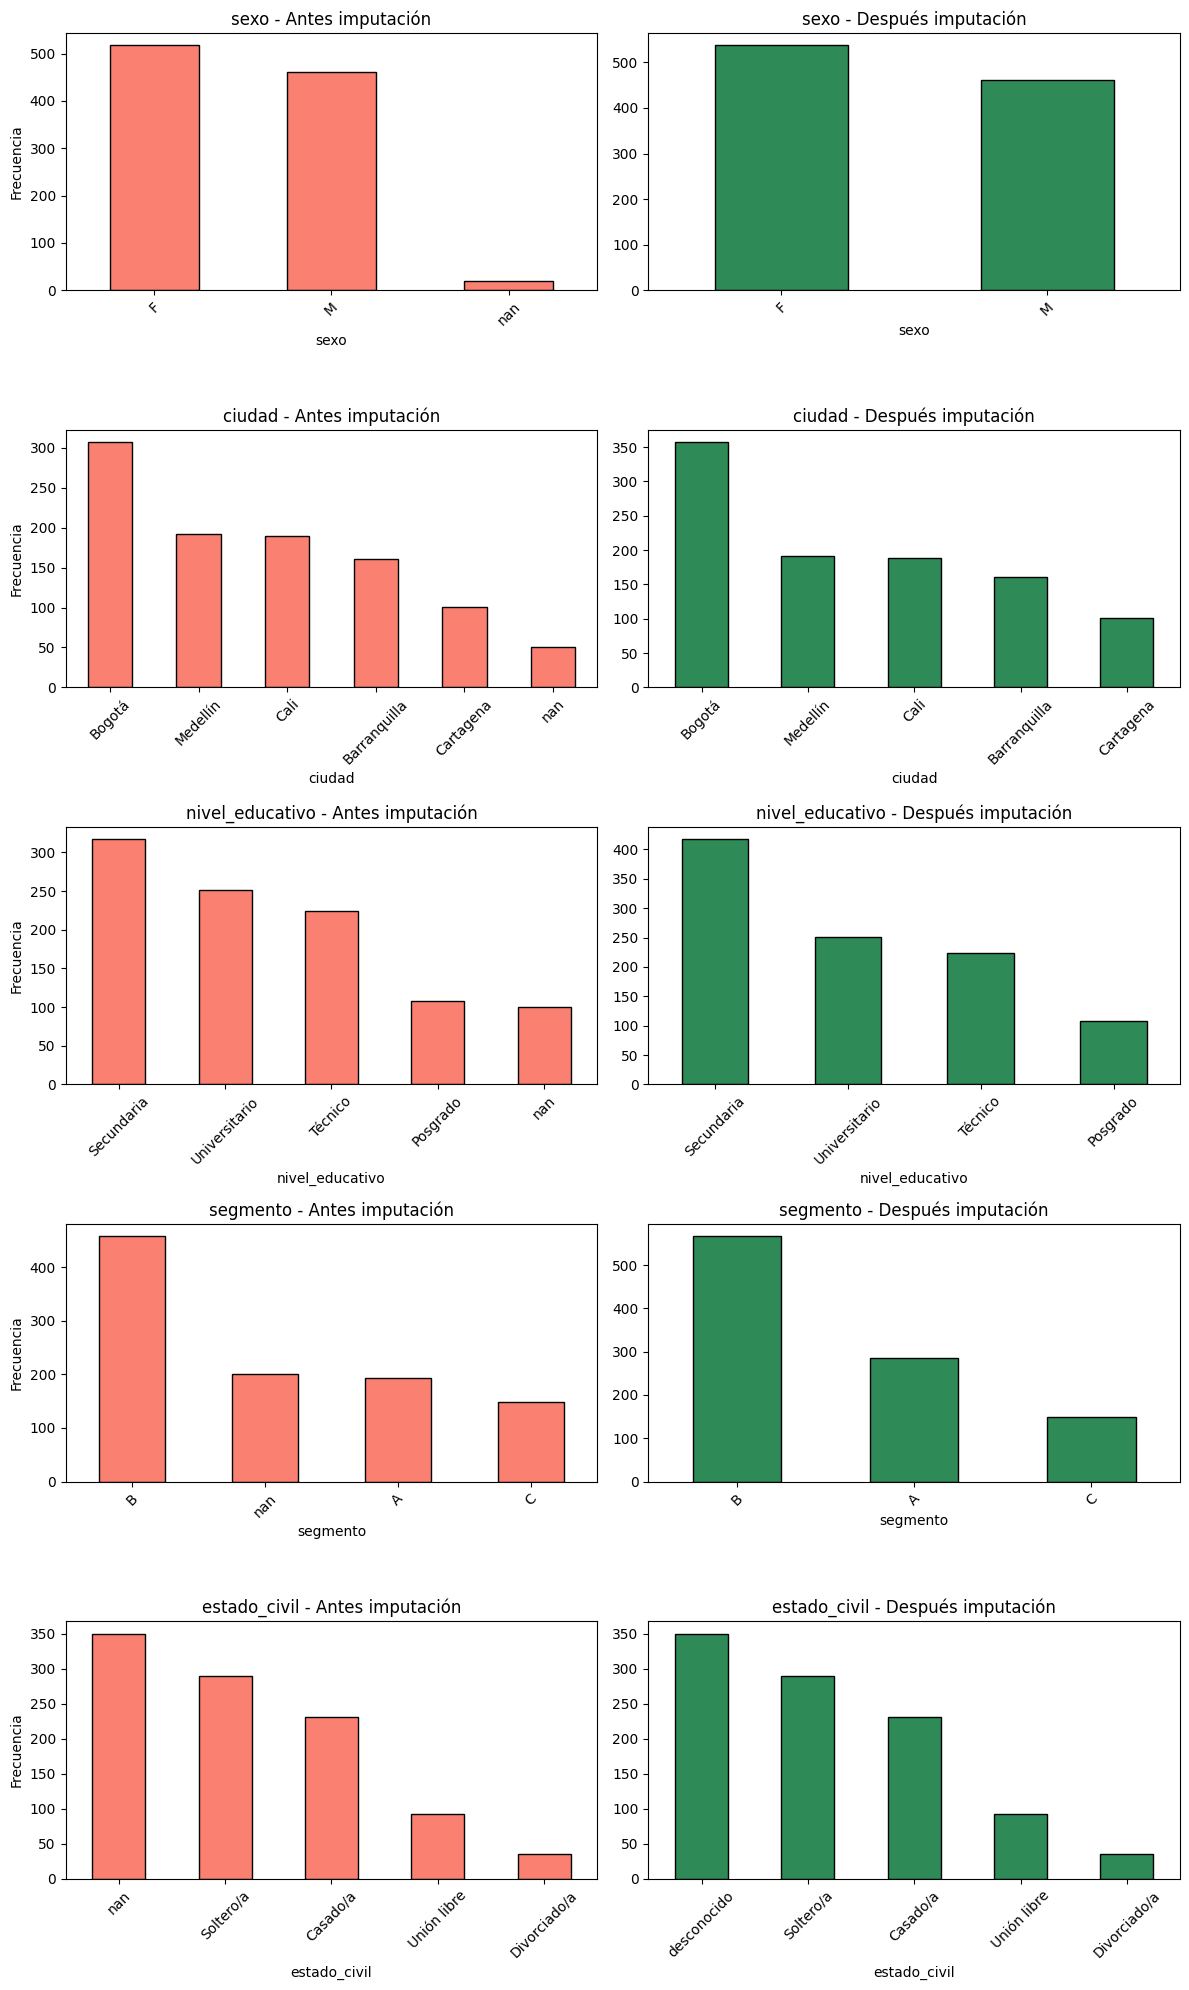

In [87]:
# --- Histogramas para numéricas ---
num_vars = df_num.columns
n = len(num_vars)

fig, axes = plt.subplots(n, 2, figsize=(12, 4*n))

for i, col in enumerate(num_vars):
    # Antes
    df[col].dropna().hist(ax=axes[i,0], bins=20, color="salmon", edgecolor="black")
    axes[i,0].set_title(f"{col} - Antes imputación")
    axes[i,0].set_ylabel("Frecuencia")
    
    # Después
    df_num[col].hist(ax=axes[i,1], bins=20, color="seagreen", edgecolor="black")
    axes[i,1].set_title(f"{col} - Después imputación")

plt.tight_layout()
plt.show()


# --- Barras para categóricas ---
cat_vars = df_cat.columns
n = len(cat_vars)

fig, axes = plt.subplots(n, 2, figsize=(12, 4*n))

for i, col in enumerate(cat_vars):
    # Antes
    df[col].value_counts(dropna=False).plot(
        kind="bar", ax=axes[i,0], color="salmon", edgecolor="black"
    )
    axes[i,0].set_title(f"{col} - Antes imputación")
    axes[i,0].set_ylabel("Frecuencia")
    axes[i,0].tick_params(axis="x", rotation=45)
    
    # Después
    df_cat[col].value_counts().plot(
        kind="bar", ax=axes[i,1], color="seagreen", edgecolor="black"
    )
    axes[i,1].set_title(f"{col} - Después imputación")
    axes[i,1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Evaluacion de la imputacion

In [91]:
normalidad_dict = {
    "altura_cm": True,
    "ingresos": True,
    "gasto_mensual": True,
    "puntuacion_credito": True,
    "edad": False,
    "demanda": False
}

# Para recorrer fácilmente
variables = list(normalidad_dict.keys())
es_normal = list(normalidad_dict.values())

# --- Comparación de distribuciones ---
from scipy.stats import ttest_ind, mannwhitneyu, ks_2samp
import pandas as pd

resultados = []

for var, normal in zip(variables, es_normal):
    before = df[var].dropna()
    after = df_num[var]
    
    if normal:
        stat, pval = ttest_ind(before, after, equal_var=False)
        test_name = "t-test"
    else:
        stat, pval = mannwhitneyu(before, after, alternative="two-sided")
        test_name = "Mann-Whitney U"
    
    ks_stat, ks_pval = ks_2samp(before, after)
    
    resultados.append({
        "variable": var,
        "test_usado": test_name,
        "stat": stat,
        "p_value": pval,
        "ks_stat": ks_stat,
        "ks_p_value": ks_pval
    })

resultados_df = pd.DataFrame(resultados)
print(resultados_df)

             variable      test_usado          stat   p_value   ks_stat  \
0           altura_cm          t-test  0.000000e+00  1.000000  0.040174   
1            ingresos          t-test  0.000000e+00  1.000000  0.060273   
2       gasto_mensual          t-test -8.558774e-15  1.000000  0.127000   
3  puntuacion_credito          t-test           NaN       NaN       NaN   
4                edad  Mann-Whitney U  4.850750e+05  0.995290  0.014784   
5             demanda  Mann-Whitney U  4.256000e+05  0.958234  0.075706   

   ks_p_value  
0    0.407949  
1    0.063341  
2    0.000002  
3         NaN  
4    0.999847  
5    0.009672  


dados los resultados se concluye lo siguiente:
- Altura: Imputación adecuada, sin distorsión.
- Ingresos: Se preserva bastante bien, aunque hay un leve cambio en la forma de la distribución
- Gasto mensual: Aquí la imputación alteró la forma de la distribución, probablemente porque la relación con ingresos es fuerte
- Puntuacion credito: no se realizó imputacion
- edad: Imputación excelente, no afectó la distribución
- demanda: El método conservó la mediana, pero modificó la forma de la distribución

In [89]:
results_cat = []

for col in df_cat.columns:
    before_counts = df[col].value_counts(dropna=True, normalize=True)
    after_counts = df_cat[col].value_counts(normalize=True)

    # Reindexar para que coincidan las categorías
    all_idx = before_counts.index.union(after_counts.index)
    before_counts = before_counts.reindex(all_idx, fill_value=0)
    after_counts = after_counts.reindex(all_idx, fill_value=0)

    # Chi-cuadrado
    chi_stat, chi_p = chisquare(f_obs=after_counts, f_exp=before_counts)

    results_cat.append({
        "Variable": col,
        "Chi2 p-valor": chi_p
    })

results_cat_df = pd.DataFrame(results_cat)
print(results_cat_df)

          Variable  Chi2 p-valor
0             sexo      0.984930
1           ciudad      0.999997
2  nivel_educativo      0.999340
3         segmento      0.992555
4     estado_civil      0.000000


c:\Users\migue\miniconda3\envs\ml_venv\lib\site-packages\scipy\stats\_stats_py.py:7985: RuntimeWarning: divide by zero encountered in divide
  terms = (f_obs_float - f_exp)**2 / f_exp


podemos observar que para todas las variabels categoricas se mantiene la distribucion excepto para estado civil (por la nueva categoria)

## Conclusion preliminar

La evaluación de la imputación muestra un panorama mixto en términos de preservación de la información original. En las variables con bajo porcentaje de valores faltantes y distribuciones bien definidas, como edad, altura_cm e incluso ingresos, la imputación fue altamente efectiva: las pruebas estadísticas indican que no hubo cambios significativos ni en tendencia central ni en la forma de la distribución, lo que asegura que los datos imputados se integraron de manera coherente con los valores existentes.

En contraste, variables con un nivel de ausencia moderado a alto, como gasto_mensual y demanda, aunque mantuvieron sus medidas de tendencia central (medias o medianas), mostraron alteraciones en la forma de la distribución. Esto sugiere que la imputación introdujo cierta distorsión, posiblemente debido a la dependencia estructural de estas variables con otras características (como ingresos), lo que limitó la capacidad de los métodos aplicados para reproducir fielmente la variabilidad original.

El caso más crítico corresponde a puntuacion_credito, con un 50% de valores faltantes. Aquí la imputación resultó poco confiable, al punto de no poder realizarse adecuadamente. El nivel de ausencia hace que cualquier método aplicado corra un alto riesgo de introducir sesgos significativos, por lo que esta variable debería ser considerada con cautela: ya sea mediante técnicas más sofisticadas de imputación múltiple o directamente evaluando su exclusión del análisis.

En síntesis, la imputación fue adecuada y efectiva en variables con pocos faltantes, aceptable pero con distorsiones en aquellas con ausencia moderada, y muy cuestionable en las que presentan una proporción elevada de valores perdidos. Esto confirma que la imputación no es un proceso neutro: su efectividad depende tanto de la magnitud del problema de datos faltantes como de la naturaleza estadística de cada variable.

| Variable            | % Nulos | Tipo de ausencia | Método sugerido de imputación                | Evidencia de preservación de la distribución |
|---------------------|---------|------------------|-----------------------------------------------|-----------------------------------------------|
| edad                | 3%      | MCAR             | Mediana (no normal)                          |  Mantiene la distribución (Mann-Whitney y KS no significativos) |
| altura_cm           | 8%      | MCAR             | Media (normal)                               |  Mantiene la distribución (t-test y KS no significativos) |
| ingresos            | 12%     | MAR              | KNN Imputer o regresión múltiple             |  Conserva medias, pero ligera alteración en forma (KS cercano a 0.05) |
| demanda             | 15%     | MAR              | Métodos robustos (KNN, MICE). Alternativa: eliminar registros si es predictora |  Mantiene tendencia central, pero distribución alterada (KS significativo) |
| gasto_mensual       | 25%     | MAR              | Imputación multivariada (MICE, KNN)          |  Media estable, pero forma distorsionada (KS muy significativo) |
| puntuacion_credito  | 50%     | MNAR             | Imputación múltiple avanzada o categoría especial; considerar eliminar |  Alta pérdida de información, no se pudo validar preservación |
| sexo                | 2%      | MCAR             | Moda                                         |  Muy fácil, bajo riesgo de sesgo |
| ciudad              | 5%      | MAR              | Moda, con cautela para evitar desbalance     |  Riesgo de alterar proporciones |
| nivel_educativo     | 10%     | MAR              | Moda o imputación basada en edad/ingresos    |  Puede sesgar, mejor usar predictores |
| segmento            | 20%     | MAR              | Algoritmos predictivos (árboles, KNN)        |  Dependiente de gasto/ingresos, riesgo moderado de distorsión |
| estado_civil        | 35%     | MNAR             | Modelo supervisado o nueva categoría “desconocido” |  Alto riesgo de sesgo, imputación incierta |